# Exploratory Data Analysis

In [2]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [3]:
df = pd.read_csv("data.csv")
df.head

<bound method NDFrame.head of        Student_ID Major_Category Year_of_Study  Pre_Semester_GPA  \
0          100001     Humanities        Senior             2.418   
1          100002        Medical        Junior             3.821   
2          100003       Business      Freshman             3.398   
3          100004       Business        Senior             3.789   
4          100005           STEM     Sophomore             3.635   
...           ...            ...           ...               ...   
49995      149996       Business        Senior             2.899   
49996      149997           STEM        Senior             2.870   
49997      149998       Business        Senior             3.177   
49998      149999       Business        Junior             3.398   
49999      150000           Arts     Sophomore             3.242   

       Weekly_GenAI_Hours           Primary_Use_Case Prompt_Engineering_Skill  \
0                   23.31       Copywriting/Drafting                 Beg

# Data Cleaning

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

### Missing Values & Duplicates

In [5]:
# Missing values per column
df.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [6]:
# Duplicate rows and duplicate Student_IDs
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Student_IDs:", df['Student_ID'].duplicated().sum())

Duplicate rows: 0
Duplicate Student_IDs: 0


### Range & Validity Checks

In [7]:
# GPA columns should be within 0-4
print(df[['Pre_Semester_GPA', 'Post_Semester_GPA']].describe())

invalid_pre_gpa = df[(df['Pre_Semester_GPA'] < 0) | (df['Pre_Semester_GPA'] > 4)]
invalid_post_gpa = df[(df['Post_Semester_GPA'] < 0) | (df['Post_Semester_GPA'] > 4)]
print("Invalid Pre_Semester_GPA rows:", len(invalid_pre_gpa))
print("Invalid Post_Semester_GPA rows:", len(invalid_post_gpa))

       Pre_Semester_GPA  Post_Semester_GPA
count      50000.000000       50000.000000
mean           3.146102           3.349299
std            0.478854           0.495673
min            1.183000           1.000000
25%            2.834000           3.023750
50%            3.210000           3.421000
75%            3.521000           3.749000
max            3.998000           4.000000
Invalid Pre_Semester_GPA rows: 0
Invalid Post_Semester_GPA rows: 0


In [8]:
# Hours columns shouldn't be negative or exceed 168 hours/week
print(df[['Weekly_GenAI_Hours', 'Traditional_Study_Hours']].describe())

invalid_genai_hours = df[(df['Weekly_GenAI_Hours'] < 0) | (df['Weekly_GenAI_Hours'] > 168)]
invalid_study_hours = df[(df['Traditional_Study_Hours'] < 0) | (df['Traditional_Study_Hours'] > 168)]
print("Invalid Weekly_GenAI_Hours rows:", len(invalid_genai_hours))
print("Invalid Traditional_Study_Hours rows:", len(invalid_study_hours))

       Weekly_GenAI_Hours  Traditional_Study_Hours
count        50000.000000             50000.000000
mean             8.427752                11.209271
std              8.269490                 5.156426
min              0.000000                 1.000000
25%              2.390000                 7.560000
50%              5.800000                11.180000
75%             11.720000                14.710000
max             40.000000                35.860000
Invalid Weekly_GenAI_Hours rows: 0
Invalid Traditional_Study_Hours rows: 0


In [9]:
# Skill_Retention_Score should be within 0-100
print(df['Skill_Retention_Score'].describe())

invalid_retention = df[(df['Skill_Retention_Score'] < 0) | (df['Skill_Retention_Score'] > 100)]
print("Invalid Skill_Retention_Score rows:", len(invalid_retention))

count    50000.000000
mean        75.798125
std         13.281626
min         10.780000
25%         66.820000
50%         76.000000
75%         85.190000
max        100.000000
Name: Skill_Retention_Score, dtype: float64
Invalid Skill_Retention_Score rows: 0


In [10]:
# Check the value range of scale/rating columns
for col in ['Tool_Diversity', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams']:
    print(col, "->", sorted(df[col].unique()))

Tool_Diversity -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Perceived_AI_Dependency -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Anxiety_Level_During_Exams -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


### Categorical Consistency Checks

In [11]:
# Check for unexpected values, typos, or inconsistent casing in categorical columns
categorical_cols = ['Major_Category', 'Year_of_Study', 'Primary_Use_Case',
                     'Prompt_Engineering_Skill', 'Institutional_Policy', 'Burnout_Risk_Level']

for col in categorical_cols:
    print(col, "->", df[col].unique())

Major_Category -> <StringArray>
['Humanities', 'Medical', 'Business', 'STEM', 'Arts']
Length: 5, dtype: str
Year_of_Study -> <StringArray>
['Senior', 'Junior', 'Freshman', 'Sophomore', 'Graduate']
Length: 5, dtype: str
Primary_Use_Case -> <StringArray>
[     'Copywriting/Drafting',                  'Ideation',
       'Summarizing_Reading', 'Debugging/Troubleshooting',
  'Direct_Answer_Generation']
Length: 5, dtype: str
Prompt_Engineering_Skill -> <StringArray>
['Beginner', 'Advanced', 'Intermediate']
Length: 3, dtype: str
Institutional_Policy -> <StringArray>
['Allowed_With_Citation', 'Strict_Ban', 'Actively_Encouraged']
Length: 3, dtype: str
Burnout_Risk_Level -> <StringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str


### Dtype Conversions

In [12]:
# Plain categoricals
for col in ['Major_Category', 'Primary_Use_Case', 'Institutional_Policy']:
    df[col] = df[col].astype('category')

# Ordered categoricals
df['Year_of_Study'] = pd.Categorical(df['Year_of_Study'],
    categories=['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate'], ordered=True)

df['Prompt_Engineering_Skill'] = pd.Categorical(df['Prompt_Engineering_Skill'],
    categories=['Beginner', 'Intermediate', 'Advanced'], ordered=True)

df['Burnout_Risk_Level'] = pd.Categorical(df['Burnout_Risk_Level'],
    categories=['Low', 'Medium', 'High'], ordered=True)

df.dtypes

Student_ID                       int64
Major_Category                category
Year_of_Study                 category
Pre_Semester_GPA               float64
Weekly_GenAI_Hours             float64
Primary_Use_Case              category
Prompt_Engineering_Skill      category
Tool_Diversity                   int64
Paid_Subscription                 bool
Traditional_Study_Hours        float64
Perceived_AI_Dependency          int64
Institutional_Policy          category
Anxiety_Level_During_Exams       int64
Post_Semester_GPA              float64
Skill_Retention_Score          float64
Burnout_Risk_Level            category
dtype: object

# Usage Patterns

## Distributions

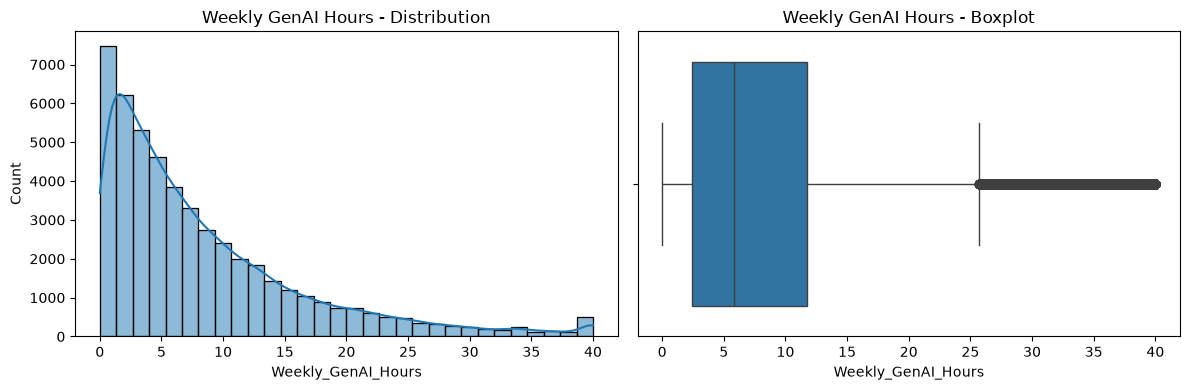

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Weekly_GenAI_Hours'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Weekly GenAI Hours - Distribution')

sns.boxplot(x=df['Weekly_GenAI_Hours'], ax=axes[1])
axes[1].set_title('Weekly GenAI Hours - Boxplot')

plt.tight_layout()
plt.show()

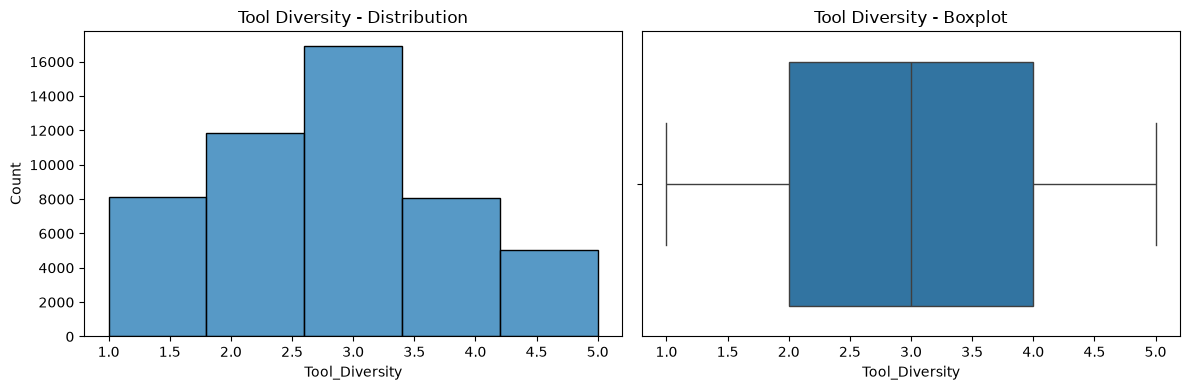

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Tool_Diversity'], bins=5, kde=False, ax=axes[0])
axes[0].set_title('Tool Diversity - Distribution')

sns.boxplot(x=df['Tool_Diversity'], ax=axes[1])
axes[1].set_title('Tool Diversity - Boxplot')

plt.tight_layout()
plt.show()

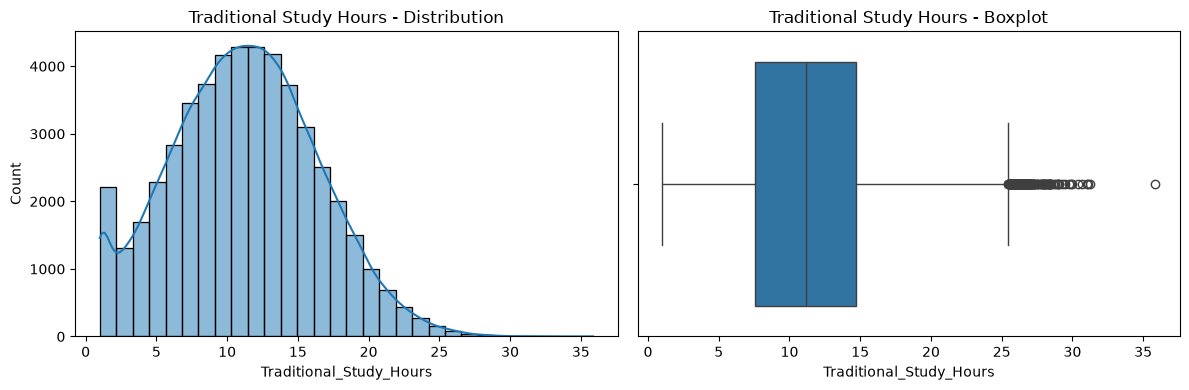

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Traditional_Study_Hours'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Traditional Study Hours - Distribution')

sns.boxplot(x=df['Traditional_Study_Hours'], ax=axes[1])
axes[1].set_title('Traditional Study Hours - Boxplot')

plt.tight_layout()
plt.show()

## Major Category vs Primary Use Case

In [16]:
# Cross-tab: counts of Primary_Use_Case per Major_Category
cross_tab = pd.crosstab(df['Major_Category'], df['Primary_Use_Case'])
cross_tab

Primary_Use_Case,Copywriting/Drafting,Debugging/Troubleshooting,Direct_Answer_Generation,Ideation,Summarizing_Reading
Major_Category,,,,,
Arts,2601,821,823,845,843
Business,1608,1640,1649,6003,1638
Humanities,5188,1162,1139,1251,1254
Medical,799,879,866,832,3100
STEM,1815,7793,1863,1790,1798


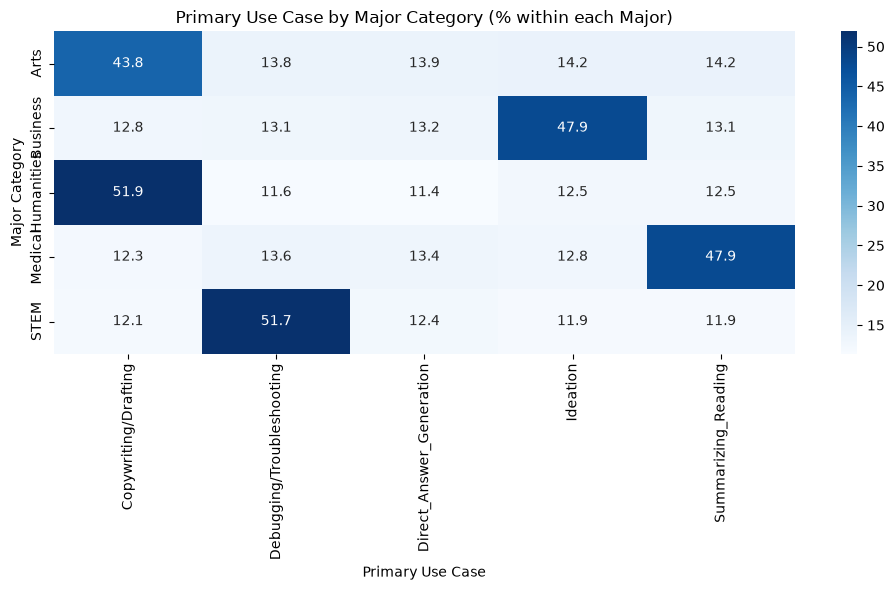

In [17]:
# Normalize by row so each Major_Category sums to 100% - easier to compare proportions across majors
cross_tab_pct = pd.crosstab(df['Major_Category'], df['Primary_Use_Case'], normalize='index') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab_pct, annot=True, fmt='.1f', cmap='Blues')
plt.title('Primary Use Case by Major Category (% within each Major)')
plt.ylabel('Major Category')
plt.xlabel('Primary Use Case')
plt.tight_layout()
plt.show()

## Prompt Engineering Skill vs Year of Study

In [18]:
# Cross-tab: counts of Prompt_Engineering_Skill per Year_of_Study
skill_by_year = pd.crosstab(df['Year_of_Study'], df['Prompt_Engineering_Skill'])
skill_by_year

Prompt_Engineering_Skill,Beginner,Intermediate,Advanced
Year_of_Study,,,
Freshman,4114,3907,3010
Sophomore,3593,3487,2780
Junior,4107,3960,2978
Senior,3925,3743,2966
Graduate,2756,2599,2075


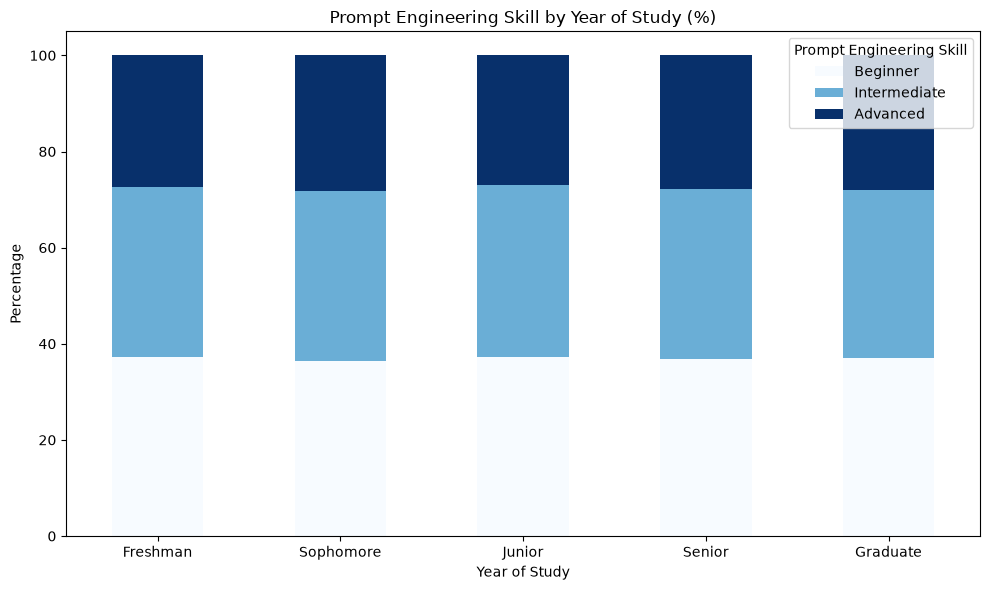

In [19]:
# Normalize by row so each Year_of_Study sums to 100% - shows skill progression across years
skill_by_year_pct = pd.crosstab(df['Year_of_Study'], df['Prompt_Engineering_Skill'], normalize='index') * 100

skill_by_year_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Blues')
plt.title('Prompt Engineering Skill by Year of Study (%)')
plt.ylabel('Percentage')
plt.xlabel('Year of Study')
plt.legend(title='Prompt Engineering Skill')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Institutional Policy vs Weekly GenAI Hours

In [20]:
# Summary stats of Weekly_GenAI_Hours grouped by Institutional_Policy
df.groupby('Institutional_Policy')['Weekly_GenAI_Hours'].describe()

,count,mean,std,min,25%,50%,75%,max
Institutional_Policy,,,,,,,,
Actively_Encouraged,14988.0,8.478409,8.264412,0.0,2.3900,5.855,11.8925,40.0
Allowed_With_Citation,25224.0,8.420150,8.310485,0.0,2.3800,5.740,11.7225,40.0
Strict_Ban,9788.0,8.369773,8.171158,0.0,2.4575,5.830,11.4725,40.0


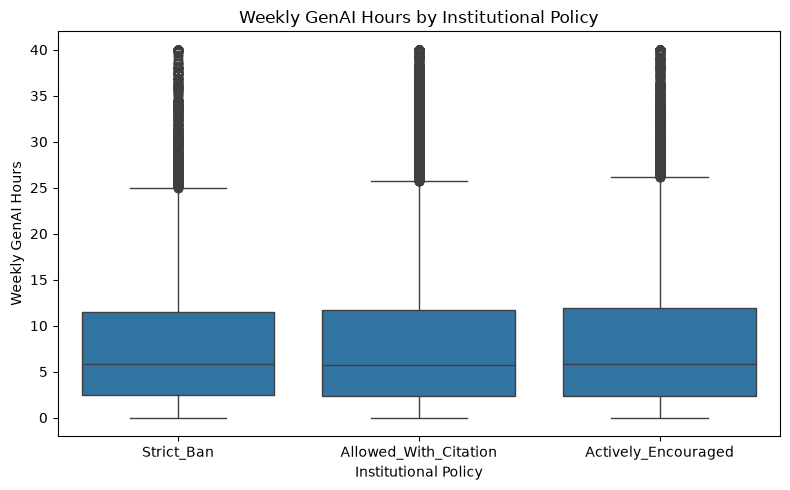

In [21]:
# Boxplot: does GenAI usage differ by institutional policy?
plt.figure(figsize=(8, 5))
sns.boxplot(x='Institutional_Policy', y='Weekly_GenAI_Hours', data=df,
            order=['Strict_Ban', 'Allowed_With_Citation', 'Actively_Encouraged'])
plt.title('Weekly GenAI Hours by Institutional Policy')
plt.xlabel('Institutional Policy')
plt.ylabel('Weekly GenAI Hours')
plt.tight_layout()
plt.show()

## Paid Subscription vs Tool Diversity / Weekly GenAI Hours

In [22]:
# Summary stats grouped by Paid_Subscription
df.groupby('Paid_Subscription')[['Tool_Diversity', 'Weekly_GenAI_Hours']].describe()

Tool_Diversity                                               \
                           count      mean       std  min  25%  50%  75%  max   
Paid_Subscription                                                               
False                    28846.0  2.794356  1.187911  1.0  2.0  3.0  4.0  5.0   
True                     21154.0  2.808310  1.188150  1.0  2.0  3.0  4.0  5.0   

                  Weekly_GenAI_Hours                                        \
                               count       mean       std  min   25%   50%   
Paid_Subscription                                                            
False                        28846.0   7.033095  7.152232  0.0  2.12  4.92   
True                         21154.0  10.329533  9.252773  0.0  2.94  7.62   

                                  
                       75%   max  
Paid_Subscription                 
False               9.3000  40.0  
True               15.3075  40.0

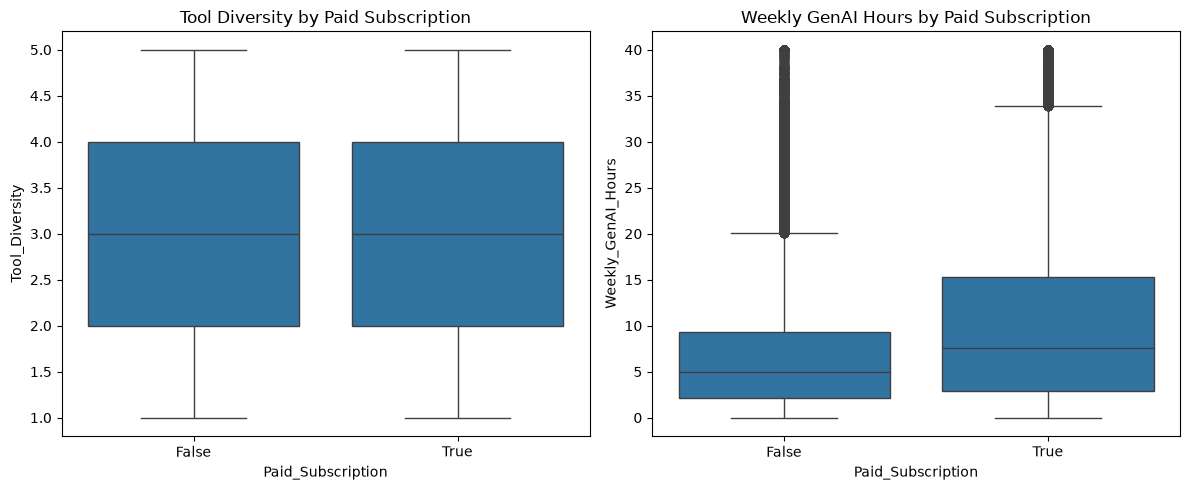

In [23]:
# Do paid users use AI more, and more diversely?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='Paid_Subscription', y='Tool_Diversity', data=df, ax=axes[0])
axes[0].set_title('Tool Diversity by Paid Subscription')

sns.boxplot(x='Paid_Subscription', y='Weekly_GenAI_Hours', data=df, ax=axes[1])
axes[1].set_title('Weekly GenAI Hours by Paid Subscription')

plt.tight_layout()
plt.show()

## Observations - Usage Patterns

- **Weekly GenAI Hours**: Most students (~70%) use GenAI tools for 0-10 hours/week, with a long right tail — a smaller group of heavy users exceeds 25 hours/week (flagged as statistical outliers).
- **Tool Diversity**: Students use on average ~2.8 distinct AI tools (median 3), suggesting most students rely on a small handful of tools rather than one or many.
- **Traditional Study Hours**: Averages ~11 hours/week, roughly comparable in magnitude to GenAI usage for heavy users.
- **Primary Use Case by Major**: Each major has a clear dominant use case — STEM leans toward Debugging/Troubleshooting, Arts and Humanities toward Copywriting/Drafting, Business toward Ideation, and Medical toward Summarizing/Reading. This suggests AI usage is shaped by the nature of coursework in each field.
- **Prompt Engineering Skill by Year of Study**: Skill level distribution (Beginner/Intermediate/Advanced) is nearly identical across Freshman through Graduate. Skill does not appear to improve with academic seniority, which is somewhat unexpected.
- **Institutional Policy vs Usage**: Weekly GenAI hours are nearly the same regardless of whether a school's policy is Strict_Ban, Allowed_With_Citation, or Actively_Encouraged. Policy does not appear to meaningfully affect how much students actually use AI.
- **Paid Subscription**: Tool diversity is essentially the same between paid and unpaid users, but paid subscribers spend noticeably more time using GenAI (median ~7.6 hrs/week vs ~4.9 hrs/week for unpaid).

**Open questions for joint synthesis**: Does the lack of skill progression by year, or the lack of policy effect on usage, correlate with anything in the outcomes/well-being data (GPA change, burnout, anxiety)?

# Outcomes and Wellbeing

## GPA Change Variable

In [24]:
df['GPA_Change'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']

## Distribution of GPA Change

In [25]:
print("Mean:", df['GPA_Change'].mean())
print("Median:", df['GPA_Change'].median())

Mean: 0.20319708000000003
Median: 0.20399999999999974


## GPA Percent Improved vs Declined

In [26]:
improved = (df['GPA_Change'] > 0).sum()
declined = (df['GPA_Change'] < 0).sum()

print("Improved:", improved)
print("Declined:", declined)

print("% Improved:", improved/len(df)*100)
print("% Declined:", declined/len(df)*100)

Improved: 43759
Declined: 6192
% Improved: 87.518
% Declined: 12.384


## Histogram of GPA Change Distribution

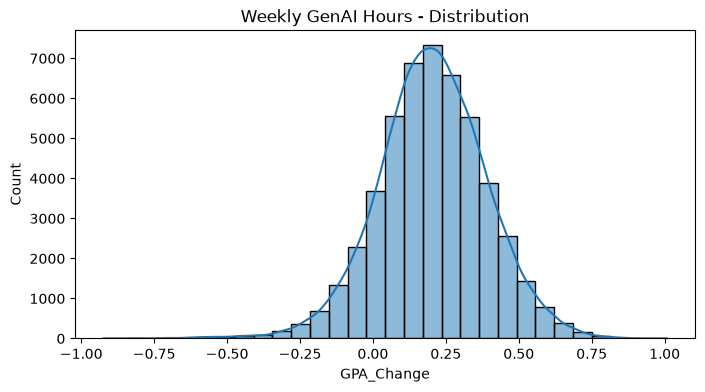

In [27]:
fig, axes = plt.subplots(1, figsize=(8, 4))

sns.histplot(df['GPA_Change'], bins=30, kde=True, ax=axes)
axes.set_title('Weekly GenAI Hours - Distribution')

plt.show()

## Scatterplot GPA Change vs Weekly GenAI Hours

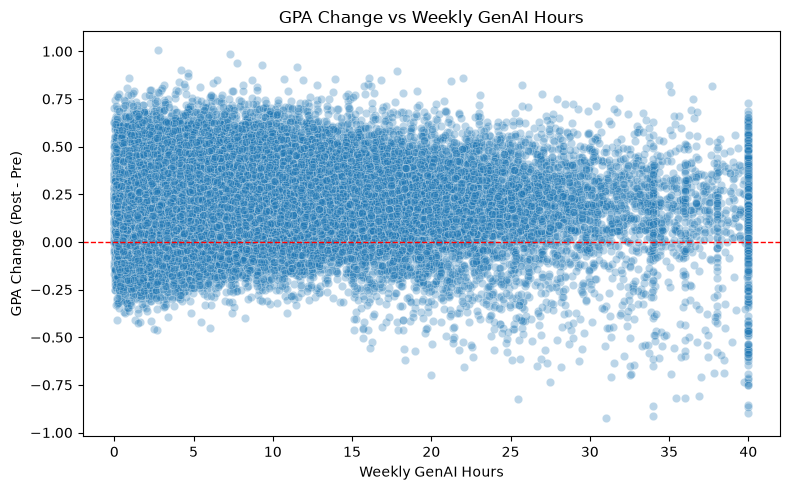

In [28]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Weekly_GenAI_Hours', y='GPA_Change', data=df, alpha=0.3)

plt.title('GPA Change vs Weekly GenAI Hours')
plt.xlabel('Weekly GenAI Hours')
plt.ylabel('GPA Change (Post - Pre)')
plt.axhline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

## Correlation GPA Change vs Weekly GenAI Hours

In [29]:
corr = df['Weekly_GenAI_Hours'].corr(df['GPA_Change'])
print(f"Correlation: {corr:.4f}") 

Correlation: -0.0465


## Skill Retention by GenAI Usage Group & Prompt Engineering Skill

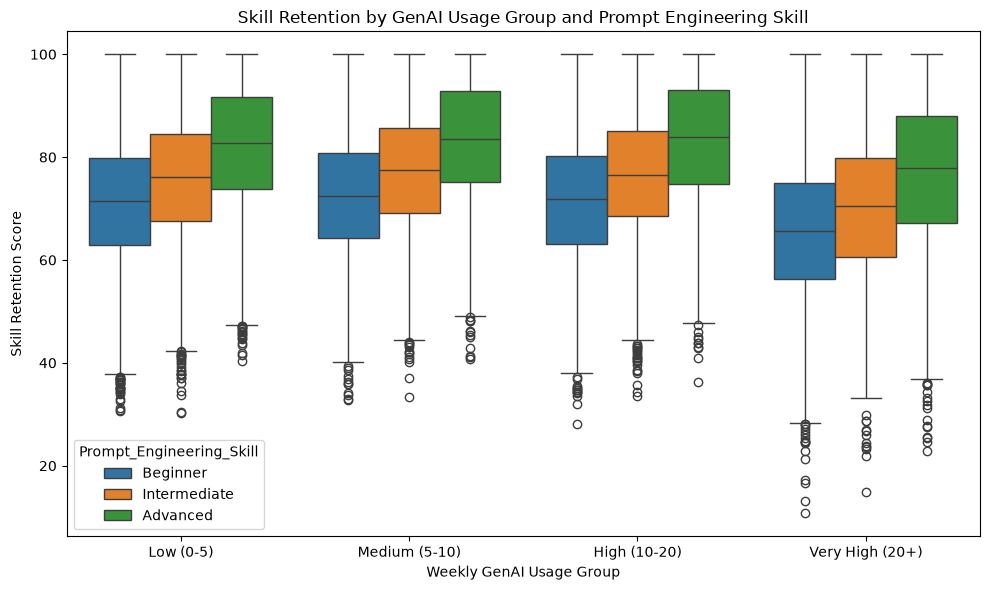

In [30]:
df['GenAI_Usage_Group'] = pd.cut(df['Weekly_GenAI_Hours'],
    bins=[0, 5, 10, 20, 40],
    labels=['Low (0-5)', 'Medium (5-10)', 'High (10-20)', 'Very High (20+)'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='GenAI_Usage_Group', y='Skill_Retention_Score',
            hue='Prompt_Engineering_Skill', data=df,
            hue_order=['Beginner', 'Intermediate', 'Advanced'])

plt.title('Skill Retention by GenAI Usage Group and Prompt Engineering Skill')
plt.xlabel('Weekly GenAI Usage Group')
plt.ylabel('Skill Retention Score')

plt.tight_layout()
plt.show()

# explain about how we choose to just do the 2 variables below cause ai usage provided not much meaningful info

## Skill Retention Score by Prompt Engineering Skill

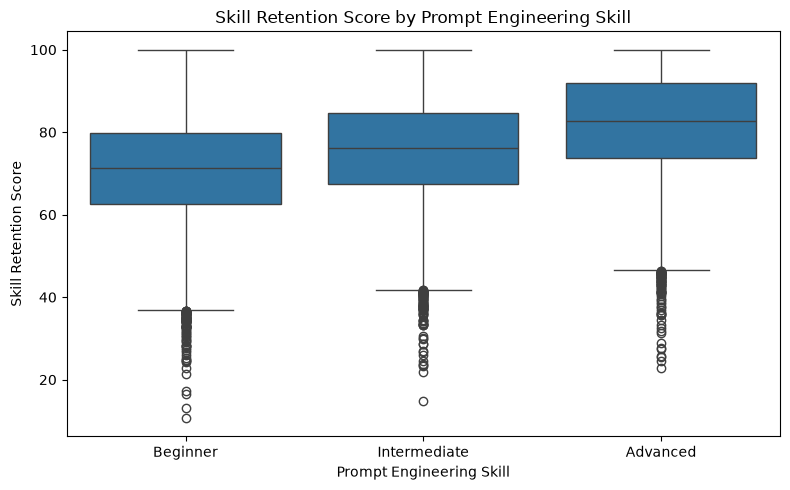

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Prompt_Engineering_Skill', y='Skill_Retention_Score', data=df,
            order=['Beginner', 'Intermediate', 'Advanced'])

plt.title('Skill Retention Score by Prompt Engineering Skill')
plt.xlabel('Prompt Engineering Skill')
plt.ylabel('Skill Retention Score')

plt.tight_layout()
plt.show()

## Weekly GenAI Hours & Traditional Study Hours by Burnout Risk Level 

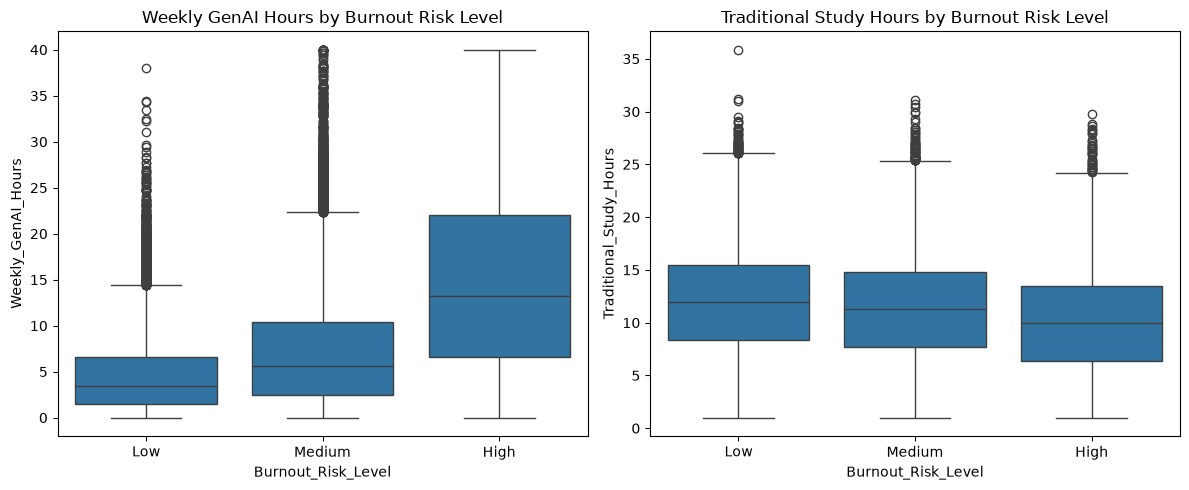

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='Burnout_Risk_Level', y='Weekly_GenAI_Hours', data=df,
            order=['Low', 'Medium', 'High'], ax=axes[0])
axes[0].set_title('Weekly GenAI Hours by Burnout Risk Level')

sns.boxplot(x='Burnout_Risk_Level', y='Traditional_Study_Hours', data=df,
            order=['Low', 'Medium', 'High'], ax=axes[1])
axes[1].set_title('Traditional Study Hours by Burnout Risk Level')

plt.tight_layout()
plt.show()

## Perceived AI Dependency by Burnout Risk Level

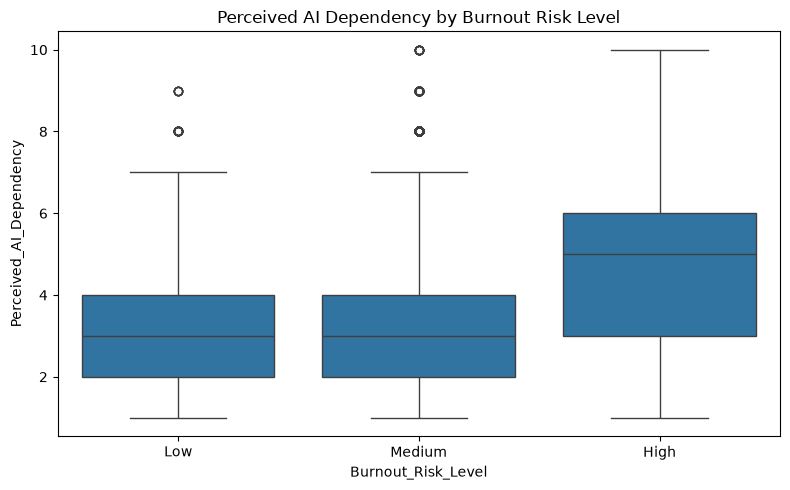

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='Burnout_Risk_Level', y='Perceived_AI_Dependency', data=df,
            order=['Low', 'Medium', 'High'])
plt.title('Perceived AI Dependency by Burnout Risk Level')

plt.tight_layout()
plt.show()

## Anxiety Level During Exams by Perceived AI Dependency

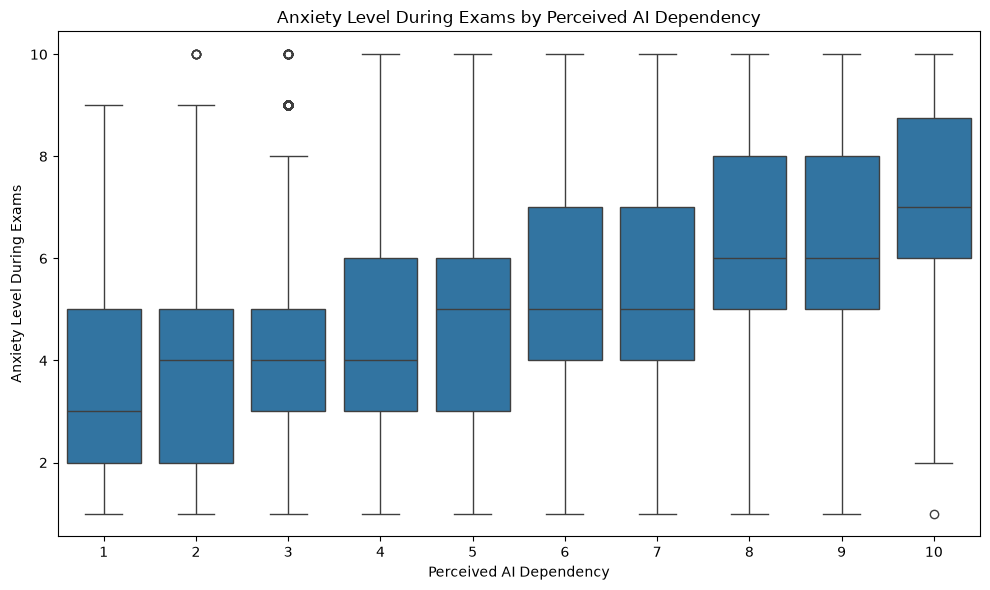

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Perceived_AI_Dependency', y='Anxiety_Level_During_Exams', data=df)

plt.title('Anxiety Level During Exams by Perceived AI Dependency')
plt.xlabel('Perceived AI Dependency')
plt.ylabel('Anxiety Level During Exams')

plt.tight_layout()
plt.show()

## Correlation of Anxiety Level During Exams and Perceived AI Dependency

In [35]:
print(df['Anxiety_Level_During_Exams'].corr(df['Perceived_AI_Dependency']))

0.30762048780249507


## Split GPA Change by Policy Group

In [36]:
strict_ban = df[df['Institutional_Policy'] == 'Strict_Ban']['GPA_Change']
allowed = df[df['Institutional_Policy'] == 'Allowed_With_Citation']['GPA_Change']
encouraged = df[df['Institutional_Policy'] == 'Actively_Encouraged']['GPA_Change']

## ANOVA Test: Any difference across all 3 groups?

In [37]:
f_stat, p_value = stats.f_oneway(strict_ban, allowed, encouraged)
print(f"ANOVA: F = {f_stat:.4f}, p = {p_value:.4f}")

ANOVA: F = 46.2936, p = 0.0000


Null Hypothesis (H₀): There is no difference in mean GPA change across the three institutional policy groups, Strict_Ban, Allowed_With_Citation, and Actively_Encouraged.
Alternative Hypothesis (H₁): At least one institutional policy group has a significantly different mean GPA change from the others.

Since p < 0.05, we reject the null hypothesis. Rejecting H₀ means we have strong statistical evidence that institutional policy affects GPA change, the three groups do not perform the same. At least one policy group leads to a meaningfully different GPA outcome.

## Pairwise T-test

In [38]:
pairs = {
    'Strict_Ban vs Allowed_With_Citation': (strict_ban, allowed),
    'Strict_Ban vs Actively_Encouraged': (strict_ban, encouraged),
    'Allowed_With_Citation vs Actively_Encouraged': (allowed, encouraged),
}

for label, (group1, group2) in pairs.items():
    t_stat, p_val = stats.ttest_ind(group1, group2)
    print(f"{label}: t = {t_stat:.4f}, p = {p_val:.4f}")

Strict_Ban vs Allowed_With_Citation: t = -9.3931, p = 0.0000
Strict_Ban vs Actively_Encouraged: t = -7.6516, p = 0.0000
Allowed_With_Citation vs Actively_Encouraged: t = 1.2097, p = 0.2264


Strict_Ban vs Allowed_With_Citation:
Strongly significant. Students in schools with a strict ban on GenAI had significantly lower GPA change compared to those in schools that allowed GenAI with citation. The negative t-value confirms the Strict_Ban group has a lower mean.

Strict_Ban vs Actively_Encouraged:
Also strongly significant. Students in strict ban schools similarly underperformed compared to those in actively encouraged schools in terms of GPA change.

Allowed_With_Citation vs Actively_Encouraged:
Not significant (p > 0.05). There is no meaningful difference in GPA change between students in schools that allow GenAI with citation versus those that actively encourage it.

Limitation to note: Running multiple t-tests increases the risk of false positives, each test carries a 5% chance of incorrectly finding a significant result. To correct for this, Tukey's HSD will be applied next as a more rigorous post-hoc test, which adjusts for multiple comparisons while confirming these findings.

## Tukey's HSD

In [39]:
tukey = pairwise_tukeyhsd(endog=df['GPA_Change'],
                           groups=df['Institutional_Policy'],
                           alpha=0.05)
print(tukey)

               Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                group2        meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------
  Actively_Encouraged Allowed_With_Citation   0.0023 0.4511 -0.0022  0.0068  False
  Actively_Encouraged            Strict_Ban  -0.0187    0.0 -0.0244  -0.013   True
Allowed_With_Citation            Strict_Ban   -0.021    0.0 -0.0262 -0.0158   True
----------------------------------------------------------------------------------


Following a significant ANOVA result, Tukey's HSD was applied as a post-hoc test to identify which specific policy groups differed while controlling for false positives across multiple comparisons.

Since both tests consistently agree, we reject the null hypothesis that all three groups have equal mean GPA change, and accept the alternative hypothesis that at least one group differs significantly. Specifically, Strict_Ban is the driving factor, banning GenAI is associated with significantly lower GPA change compared to any form of permitted GenAI usage. Meanwhile, the method of allowance (encouraged vs citation-based) makes no statistically significant difference.